In [1]:
import sys 
sys.path.append("/Users/users/wempe/lgsim")
from lgsim.postprocess_gadget import *
from pathlib import Path

In [2]:
fol = Path("/net/gaia2/data/users/wempe/rerun_169/")
folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])

In [3]:
#fol = Path("/net/gaia2/data/users/wempe/lr/")
#folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])
#70 more LR simulations

In [4]:
#fol = Path("/net/gaia2/data/users/wempe/more_highres_runs/")
#folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])
#HR simulations (~90 or so)
#a bit annoying to use because the snapshot timings are a bit different for each simulations

In [5]:
fol = folnames_new[128]

In [6]:
print(fol) #mergers.nc

/net/gaia2/data/users/wempe/rerun_169/runz98.7_mcmc_1189


In [7]:
import xarray as xr
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# save original function
_real_load_dataset = xr.load_dataset

def fixed_load_dataset(*args, **kwargs):
    kwargs["engine"] = "h5netcdf"
    kwargs["phony_dims"] = "sort"
    return _real_load_dataset(*args, **kwargs)

# monkey patch xarray
xr.load_dataset = fixed_load_dataset

In [8]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

mt = MergerTree(fol, Nsnap=209)

In [9]:
#!pip install --user netCDF4

In [10]:
#xr.open_dataset(fol / "mergers_m31.nc")

In [11]:
import xarray as xr

ds = xr.open_dataset(
    fol / "mergers_m31.nc",
    engine="h5netcdf",
    phony_dims="sort"
)

mergers_ds = ds

In [12]:
ds = xr.open_dataset(fol / "mergers_m31.nc")

In [13]:
mergers_ds = xr.open_dataset(fol / "mergers_m31.nc")

In [14]:
mergers_ds['massratio'] = mergers_ds.sel(which='subhalo', event='r200_first').SubhaloMass / mergers_ds.sel(which='mmp', event='r200_first').SubhaloMass

In [15]:
gres = GadgetRes(fol, i_snap=0)

In [16]:
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np

def sf_to_lookback(a):
    a = np.asarray(a, dtype=float)
    z = 1 / a - 1
    return Planck18.lookback_time(z).to_value(u.Gyr)

In [17]:
#here i want to find simulations with at least one merger between 2 and 4 Gyr ago, but due to the variance of 1 year i set the requirements to 1 and 5 

required_sims = [] #simulations that are required

required_min = 2 #minimum
required_max = 4 #maximum

for sim_number, fol in enumerate(folnames_new):

    try: #using try because the kernel keeps shutting down
        with xr.open_dataset(fol / "mergers_m31.nc") as ds:

            #satellite mass
            m_sat = ds["SubhaloMass"].sel(event="sat_highestmass", which="subhalo").load().values

            #main mass
            m_main = ds["SubhaloMass"].sel(event="sat_highestmass", which="main").load().values

            mass_ratio = m_sat / m_main #mass ratio

            #scale factor 
            a_destroyed = ds["scale_factor"].sel(event="destroyed", which="main").load().values
            #to lookback time
            t_destroyed = sf_to_lookback(a_destroyed)
            #only destroyed satellites
            destroyed = ~ds["survives_to_now"].load().values

            #only consider mergers with 0.05 <= μ <= 0.50
            relevant_mergers = (destroyed & np.isfinite(mass_ratio) & (mass_ratio >= 0.05))

            required = (relevant_mergers & np.isfinite(t_destroyed) & (t_destroyed >= required_min) & (t_destroyed <= required_max))
           
            #required mergers
            n_required = np.sum(required)

            #keep simulation if at least one merger satisfies my condition
            if n_required >= 1:

                required_sims.append((sim_number, fol, n_required))

    except Exception as e:

        print(f"Simulation {sim_number} failed: {fol}") #i do this because there is one that keeps on failing
        print(e)

print(
    "Simulations with at least one merger "
    "consistent with 2–4 Gyr ago (5-1 Gyr):",
    len(required_sims)
)

Simulation 27 failed: /net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869
[Errno 2] No such file or directory: '/net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869/mergers_m31.nc'
Simulations with at least one merger consistent with 2–4 Gyr ago (5-1 Gyr): 78


In [18]:
#simulation numbers with at least one merger between 2–4 Gyr ago (5-1) with amount of mergers 

print("Simulation numbers with mergers between 2–4 Gyr ago:")

for sim_number, fol, n_required in required_sims:

    print(
        f"Simulation {sim_number} "
        f"({n_required} merger)"
    )

Simulation numbers with mergers between 2–4 Gyr ago:
Simulation 1 (2 merger)
Simulation 2 (1 merger)
Simulation 6 (1 merger)
Simulation 9 (1 merger)
Simulation 13 (2 merger)
Simulation 14 (1 merger)
Simulation 15 (4 merger)
Simulation 16 (1 merger)
Simulation 17 (2 merger)
Simulation 18 (1 merger)
Simulation 20 (1 merger)
Simulation 22 (2 merger)
Simulation 28 (4 merger)
Simulation 29 (1 merger)
Simulation 30 (3 merger)
Simulation 35 (1 merger)
Simulation 36 (1 merger)
Simulation 38 (3 merger)
Simulation 39 (1 merger)
Simulation 40 (1 merger)
Simulation 41 (2 merger)
Simulation 44 (2 merger)
Simulation 45 (1 merger)
Simulation 46 (1 merger)
Simulation 47 (3 merger)
Simulation 48 (1 merger)
Simulation 51 (1 merger)
Simulation 52 (1 merger)
Simulation 53 (1 merger)
Simulation 58 (1 merger)
Simulation 60 (1 merger)
Simulation 61 (3 merger)
Simulation 62 (1 merger)
Simulation 68 (1 merger)
Simulation 69 (2 merger)
Simulation 71 (1 merger)
Simulation 75 (1 merger)
Simulation 76 (1 merger)
S

In [19]:
try:
    ds.close()
except:
    pass

try:
    mergers_ds.close()
except:
    pass

import gc
gc.collect()

1219

In [20]:
#here i want to find simulations with no merger between 4 and 8 Gyr ago, but due to the variance of 1 year i set the requirements to 5 and 7 

no_forbidden_sims = []

forbidden_min = 5 #more strict
forbidden_max = 7

for sim_number, fol in enumerate(folnames_new):

    try:
        with xr.open_dataset(fol / "mergers_m31.nc") as ds:

            #satellite mass
            m_sat = ds["SubhaloMass"].sel(event="sat_highestmass", which="subhalo").values

            #main mass
            m_main = ds["SubhaloMass"].sel(event="sat_highestmass", which="main").values

            mass_ratio = m_sat / m_main #mass ratio

            #scale factor
            a_destroyed = ds["scale_factor"].sel(event="destroyed", which="main").values
            #to lookback time
            t_destroyed = sf_to_lookback(a_destroyed)
            #only destroyed satellites
            destroyed = ~ds["survives_to_now"].values

            #mergers with 0.05 <= μ <= 0.50
            relevant_mergers = (destroyed & np.isfinite(mass_ratio) & (mass_ratio >= 0.05) & (mass_ratio <= 0.50))

            forbidden = (relevant_mergers & np.isfinite(t_destroyed) & (t_destroyed >= forbidden_min) & (t_destroyed <= forbidden_max))

            #forbidden mergers
            n_forbidden = np.sum(forbidden)

            #i keep the simulation if no forbidden mergers exist
            if n_forbidden == 0:

                no_forbidden_sims.append((sim_number, fol, n_forbidden))

    except Exception as e:

        print(f"Simulation {sim_number} failed: {fol}") #failed one for 27
        print(e)

print("Simulations with no mergers 4–8 Gyr ago (±1 Gyr):", len(no_forbidden_sims))
#kernel shuts down

Simulation 27 failed: /net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869
[Errno 2] No such file or directory: '/net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869/mergers_m31.nc'
Simulations with no mergers 4–8 Gyr ago (±1 Gyr): 67


In [21]:
#simulation numbers with no mergers between 4–8 Gyr ago

print("Simulation numbers with NO mergers between 4–8 Gyr ago:")

for sim_number, fol, n_forbidden in no_forbidden_sims:

    print(
        f"Simulation {sim_number}"
    )

Simulation numbers with NO mergers between 4–8 Gyr ago:
Simulation 0
Simulation 5
Simulation 7
Simulation 9
Simulation 10
Simulation 24
Simulation 25
Simulation 26
Simulation 35
Simulation 36
Simulation 37
Simulation 39
Simulation 43
Simulation 46
Simulation 51
Simulation 55
Simulation 56
Simulation 57
Simulation 60
Simulation 62
Simulation 63
Simulation 64
Simulation 65
Simulation 67
Simulation 70
Simulation 72
Simulation 73
Simulation 74
Simulation 75
Simulation 77
Simulation 78
Simulation 79
Simulation 82
Simulation 85
Simulation 86
Simulation 87
Simulation 88
Simulation 93
Simulation 97
Simulation 99
Simulation 104
Simulation 109
Simulation 110
Simulation 113
Simulation 116
Simulation 118
Simulation 124
Simulation 125
Simulation 128
Simulation 133
Simulation 138
Simulation 142
Simulation 143
Simulation 144
Simulation 145
Simulation 146
Simulation 150
Simulation 151
Simulation 152
Simulation 153
Simulation 155
Simulation 159
Simulation 161
Simulation 163
Simulation 164
Simulation 16

Now I want to see which simulations overlap both the conditions. Doing the conditions in seperate parts was nice because I could account for the variation better.

In [22]:
required_indices = set(sim[0] for sim in required_sims) #only simulation numbers 1-5
no_forbidden_indices = set(sim[0] for sim in no_forbidden_sims) #5-7
overlap = required_indices & no_forbidden_indices #see which ones are overlapping

print("Simulation numbers satisfying both conditions:")

for sim_number in sorted(overlap):
    print(sim_number)

Simulation numbers satisfying both conditions:
9
35
36
39
46
51
60
62
75
77
85
87
88
93
97
113
116
118
124
128
159
161


In [23]:
# #create a table from the overlap list
# overlap_table = pd.DataFrame({
#     "sim_number": sorted(overlap) #sorted simulation numbers
# })

# #cvs
# overlap_table.to_csv("overlap_simulations.csv", index=False)
# print("Saved overlap simulations to overlap_simulations.csv")

Saved overlap simulations to overlap_simulations.csv


In [24]:
import pandas as pd #import pandas for tables

total_sims = len(folnames_new) #total number of simulations

n_late_merger = len(required_sims) #number of simulations with late merger

fraction = n_late_merger / total_sims #fraction of simulations with late merger

summary = pd.DataFrame({ #make summary table
    "total_sims": [total_sims], #total simulations
    "late_merger_sims": [n_late_merger], #simulations with late merger
    "fraction": [fraction], #fract
    "percentage": [fraction * 100] #percentage
})

summary.to_csv("late_merger_summary.csv", index=False) #save summary

late_merger_table = pd.DataFrame({ #make table 
    "sim_number": [sim[0] for sim in required_sims], #simulation numbers
    "n_late_mergers": [sim[2] for sim in required_sims] #number of late mergers
})

late_merger_table.to_csv("late_merger_simulations.csv", index=False) #save table

print(f"{n_late_merger} simulations out of {total_sims} had a late merger with μ > 0.05") 
print(f"Fraction = {fraction:.2f}, or {fraction*100:.1f}%") #percentage

78 simulations out of 169 had a late merger with μ > 0.05
Fraction = 0.46, or 46.2%


In [25]:
def plot_mergertree_from_snap(mt, i, i_snap, ax=None, color='C0', axis='lookback_time'):

    if ax is None:
        ax = plt.gca()

    try:
        i = set(i)
    except TypeError:
        i = set([i])

    is_toplot = {i_snap: set(i)}

    from matplotlib.collections import LineCollection

    if axis == 'snapshot_num':
        x_axis_values = np.arange(mt.Nsnap + 1)
    else:
        a_s = mt.a_s

        if axis == 'scale_factor':
            x_axis_values = a_s
        elif axis == 'lookback_time':
            x_axis_values = Planck18.lookback_time(1/a_s - 1).to_value(u.Gyr)
        elif axis == 'cosmic_time':
            x_axis_values = Planck18.age(1/a_s - 1).to_value(u.Gyr)
        else:
            raise ValueError("Unknown x-axis")

    for snap in range(i_snap, 0, -1):
        is_toplot[snap-1] = set()
        segments = []

        for ind in is_toplot[snap]:
            fil_progs = mt.get_prog(snap, ind)

            if fil_progs is None:
                continue

            is_toplot[snap-1].update(np.where(fil_progs)[0].tolist())

            masses_progs = mt.subhalos[snap-1].SubhaloMass.values[fil_progs]

            for mass_prog in [masses_progs.max()] if len(masses_progs) > 0 else []:
                x = [x_axis_values[snap-1], x_axis_values[snap]]
                y = np.array([
                    mass_prog,
                    mt.subhalos[snap].SubhaloMass.values[ind]
                ]) * 1e10 / mt.h

                segments.append([x, y])

        if segments:
            segments = np.moveaxis(np.array(segments), -1, -2)
            lc = LineCollection(segments, linewidths=0.8, colors=color)
            ax.add_collection(lc)

    ax.set_yscale("log")
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel("Subhalo mass ($M_\odot$)")

    return is_toplot

Number of destroyed satellites with μ_R200 > 0.05: 114


/Software/users/modules/7/software/anaconda3/2024.02/lib/python3.11/site-packages/numpy/lib/function_base.py:2411: RuntimeWarning: invalid value encountered in _integral_lookback_time (vectorized)
  outputs = ufunc(*inputs)


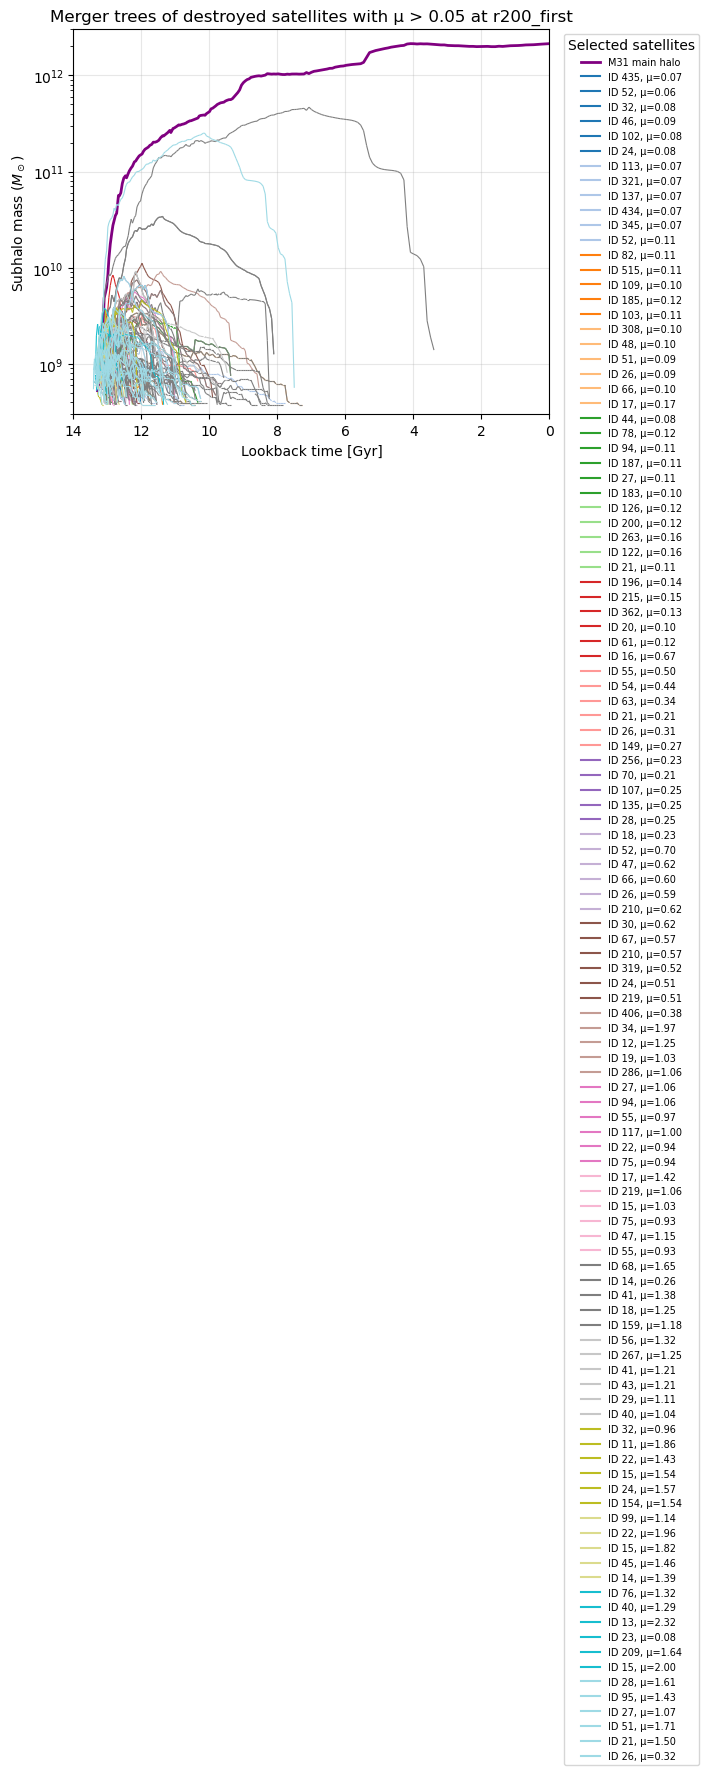

In [26]:
# mass ratio at r200_first
m_sat_fof = mergers_ds["SubhaloMass"].sel(
    event="r200_first", which="subhalo"
).values

m_main_fof = mergers_ds["SubhaloMass"].sel(
    event="r200_first", which="main"
).values

mu_fof = m_sat_fof / m_main_fof

# only destroyed satellites
destroyed = ~mergers_ds["survives_to_now"].values

# select destroyed satellites with mass ratio > 0.05 at fof_first
mask = destroyed & np.isfinite(mu_fof) & (mu_fof > 0.05)

selected_indices = np.where(mask)[0]

print(f"Number of destroyed satellites with μ_R200 > 0.05: {len(selected_indices)}")

colors = plt.cm.tab20(np.linspace(0, 1, len(selected_indices)))

fig, ax = plt.subplots(figsize=(8, 5))

# plot M31 main progenitor
m31_main_ds = get_mainprog_ds(mt, mt.i_m31, mt.Nsnap)

m31_time = Planck18.lookback_time(
    1 / m31_main_ds.scale_factor.values - 1
).to_value(u.Gyr)

m31_mass = m31_main_ds.SubhaloMass.values * 1e10 / mt.h

ax.plot(m31_time, m31_mass, color="purple", linewidth=2, label="M31 main halo")

for idx, color in zip(selected_indices, colors):

    subhalo_id_destroyed = int(
        mergers_ds["Subhalo"].sel(
            snap_subhalo_id=idx,
            which="subhalo",
            event="destroyed"
        ).values
    )

    snap_destroyed = int(
    mergers_ds["snapnum"].sel(
        snap_subhalo_id=idx,
        event="destroyed"
    ).values.flat[0]
    )


    label = f"ID {subhalo_id_destroyed}, μ={mu_fof[idx]:.2f}"

    plot_mergertree_from_snap(
        mt,
        subhalo_id_destroyed,
        snap_destroyed,
        ax=ax,
        color=color,
        axis="lookback_time"
    )

    ax.plot([], [], color=color, label=label)

ax.set_xlim(14, 0)
ax.set_ylim(3e8, 3e12)
ax.set_yscale("log")
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel("Subhalo mass ($M_\odot$)")
ax.set_title("Merger trees of destroyed satellites with μ > 0.05 at r200_first")
ax.grid(True, alpha=0.3)

ax.legend(
    fontsize=7,
    title="Selected satellites",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.subplots_adjust(right=0.72)
plt.show()

/Users/users/wempe/lgsim/lgsim/postprocess_gadget.py:318: RuntimeWarning: divide by zero encountered in divide
  x_axis_values = Planck18.age(1/a_s-1).to_value(u.Gyr)


(0.0, 14.0)

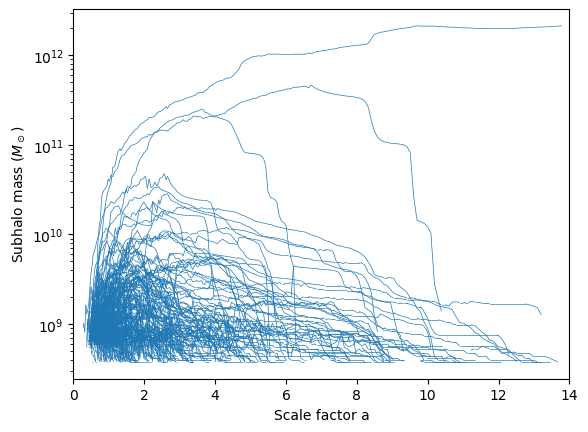

In [27]:
tree1 = mt.plot_mergertree(mt.i_m31, axis='lookback_time')
plt.xlim(0,14)